In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

# Import packages

In [24]:
import pandas as pd
import numpy as np

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

import matplotlib.pyplot as plt

# Control of a blending process

<img src="../figures/example-11-1-rl-b-1.png">

## Process Description

The system consists of a perfectly mixed tank with two inlet streams and one outlet stream. The inlet volumetric flow rates are denoted by $F_1$ and $F_2$, with corresponding inlet concentrations $x_1$ and $x_2$. The outlet flow rate depends on the liquid level in the tank. The tank cross-sectional area is constant and equal to $A$.

The controlled variables are:
- Liquid level in the tank, $h(t)$
- Outlet concentration, $x(t)$

The manipulated variable is the inlet flow rate $F_1(t)$.  
The inlet flow rate $F_2(t)$ is treated as an external disturbance.

## Dynamic Model

The system dynamics are described by the following nonlinear mass balance equations.

### Liquid Level Dynamics

The liquid level evolves according to the total inlet flow and a nonlinear outlet flow:

$A \frac{dh(t)}{dt} = F_1(t) + F_2(t) - \beta \sqrt{h(t)}$

where $\beta$ is a discharge coefficient characterizing the outlet valve.

### Concentration Dynamics

Assuming perfect mixing, the concentration dynamics are given by:


$A h(t) \frac{dx(t)}{dt} = F_1(t)\left(x_1 - x(t)\right) + F_2(t)\left(x_2 - x(t)\right)$


This equation highlights the nonlinear coupling between the tank level and concentration dynamics through the product $A h(t)$.

## Control Objective

The primary control objective is to regulate the outlet concentration $x(t)$ to a desired setpoint $x_{\mathrm{sp}}$, despite:
- nonlinear process dynamics,
- coupling between level and concentration,
- unknown or time-varying disturbances in $F_2(t)$.

Formally, the objective is to minimize the concentration tracking error:

$e(t) = x_{\mathrm{sp}} - x(t)$


while keeping the manipulated flow rate $F_1(t)$ within physical bounds and maintaining a feasible tank level.


# PID control

In [100]:
A = 1.0
beta = 0.6
x1 = 1.0
x2 = 0.0
F2 = 0.4
x_sp = 0.6

dt = 0.01
T = 40
time = np.arange(0, T, dt)

Kp = 5.0
Ki = 1.0
Kd = 0.5

h = 1.0
x = 0.2
ei = 0.0
e_prev = 0.0

h_hist_pid, x_hist_pid, F1_hist_pid = [], [], []

for _ in time:
    # PID controller
    e = x_sp - x
    ei += e * dt
    ed = (e - e_prev) / dt
    F1 = Kp * e + Ki * ei + Kd * ed
    F1 = np.clip(F1, 0.0, 2.0)

    # Nonlinear dynamics
    dhdt = (F1 + F2 - beta * np.sqrt(max(h, 0))) / A
    dxdt = (F1 * (x1 - x) + F2 * (x2 - x)) / (A * h)

    h += dhdt * dt
    x += dxdt * dt
    e_prev = e

    h_hist_pid.append(h)
    x_hist_pid.append(x)
    F1_hist_pid.append(F1)



In [ ]:
def plot_control_results(time, x_hist, h_hist, F1_hist, label = ["PID"]):
    fig = plt.figure(figsize=(12,4))
    file_name = ""

    ax1 = fig.add_subplot(1,3,1)
    for i in range(len(x_hist)):
        ax1.plot(time[i], x_hist[i], label=f"x_{label[i]}")
        file_name += f"{label[i]}_"
    ax1.axhline(x_sp, linestyle="--", label="x_sp")
    ax1.set_ylabel("Concentration")
    ax1.set_xlabel("Time")
    ax1.legend()

    ax2 = fig.add_subplot(1,3,2)
    for i in range(len(h_hist)):
        ax2.plot(time[i], h_hist[i], label=f"h_{label[i]}")
    ax2.set_ylabel("Height")
    ax2.set_xlabel("Time")
    ax2.legend()

    ax3 = fig.add_subplot(1,3,3)
    for i in range(len(F1_hist)):
        ax3.plot(time[i], F1_hist[i], label=f"F1_{label[i]}")
    ax3.set_ylabel("F1")
    ax3.set_xlabel("Time")
    ax3.legend()

    plt.tight_layout()

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=15
    plt.rcParams['axes.linewidth'] = 1 

    plt.savefig(f'figures/example-11-1-rl-b-{file_name}.png', dpi = 300)

    plt.show()

    return None

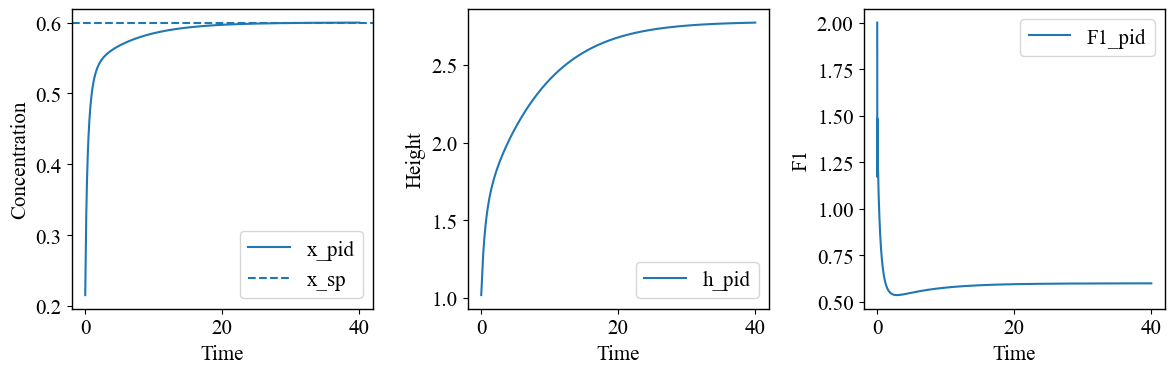

In [141]:
plot_control_results([time], [x_hist_pid], [h_hist_pid], [F1_hist_pid])

# RL control

## Enviroment

In [ ]:
class BlendingTankEnv(gym.Env):
    '''
    Environment for the blending tank process.

    The environment simulates a blending tank where the agent controls the inflow rate F1 to maintain the outlet concentration x at a desired setpoint x_sp. The state consists of the tank height h and outlet concentration x. The action is the inflow rate F1. The reward is based on the deviation of x from x_sp and penalizes large control actions.
    '''
    def __init__(self):
        super().__init__()
        self.A = 1.0
        self.beta = 0.6
        self.x1 = 1.0
        self.x2 = 0.0
        self.F2 = 0.4
        self.x_sp = 0.6
        self.dt = 0.05

        self.action_space = spaces.Box(
            low=np.float32(0.0),
            high=np.float32(2.0), 
            shape=(1,), 
            )
        
        self.observation_space = spaces.Box(
            low=np.float32(np.array([0.1, 0.0])),
            high=np.float32(np.array([3.0, 1.0])),
        )

        self.reset()

    def reset(self):
        self.h = 1.0
        self.x = 0.2
        return np.array([self.h, self.x])

    def step(self, action):
        F1 = float(action[0])

        dhdt = (F1 + self.F2 - self.beta * np.sqrt(self.h)) / self.A
        dxdt = (F1 * (self.x1 - self.x) + self.F2 * (self.x2 - self.x)) / (self.A * self.h)

        self.h += dhdt * self.dt
        self.x += dxdt * self.dt

        reward = -(self.x - self.x_sp)**2 - 0.01 * F1**2
        done = False

        return np.array([self.h, self.x]), reward, done, {}


## RL agent

In [ ]:
class DQN(nn.Module):
    def __init__(self, n_states, n_actions):
        '''
        Deep Q-Network model.
        Parameters:
        n_states (int): Number of state variables.
        n_actions (int): Number of possible actions.

        The network predicts Q-values for each action given the current state.
        '''
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions)
        )

    def forward(self, x):
        return self.net(x)


## Training

In [ ]:
# Initialize environment
env = BlendingTankEnv()

# Define a discrete action space
valve_range = (0.3, 2.0)
valve_positions = 11
actions = np.linspace(valve_range[0], valve_range[1], valve_positions)

# Initialize DQN model
model = DQN(2, len(actions))
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Memory buffer. This is a deque that stores experience tuples for experience replay.
memory = deque(maxlen=5000)

# Hyperparameters for training
gamma = 0.99
epsilon = 1.0

episode_rewards = []

# Train over 500 episodes
for episode in range(500):
    state = env.reset() # Reset environment at start of episode
    total_reward = 0.0

    # For each episode, run for 900 time steps
    for _ in range(900):
        # Sometimes explore, sometimes exploit
        if random.random() < epsilon:
            a_idx = random.randrange(len(actions))
        else:
            with torch.no_grad():
                q = model(torch.tensor(state).float())
                a_idx = torch.argmax(q).item()

        next_state, reward, _, _ = env.step([actions[a_idx]])
        memory.append((state, a_idx, reward, next_state))

        total_reward += reward
        state = next_state

        # Replay experience and train the model
        if len(memory) > 256:
            batch = random.sample(memory, 64)

            # Convert batch data to tensors
            s, a, r, ns = zip(*batch)

            s = torch.tensor(s).float()
            ns = torch.tensor(ns).float()
            a = torch.tensor(a)
            r = torch.tensor(r).float()

            # Implement Q-learning update
            q = model(s).gather(1, a.unsqueeze(1)).squeeze()
            q_next = model(ns).max(1)[0]
            target = r + gamma * q_next

            loss = ((q - target.detach())**2).mean()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    episode_rewards.append(total_reward)

    # Decay exploration rate
    epsilon *= 0.995


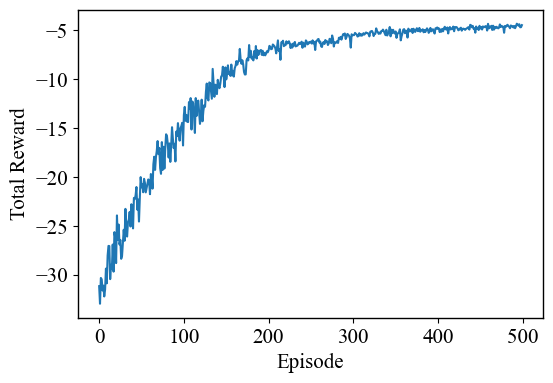

In [128]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)

ax.plot(episode_rewards)
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
plt.show()


## Run a test episode

In [129]:
state = env.reset()

h_hist_rl, x_hist_rl, F1_hist_rl = [], [], []
time_rl = []

for k in range(700):
    with torch.no_grad():
        q = model(torch.tensor(state).float())
        a_idx = torch.argmax(q).item()

    F1 = actions[a_idx]
    state, _, _, _ = env.step([F1])

    h_hist_rl.append(state[0])
    x_hist_rl.append(state[1])
    F1_hist_rl.append(F1)
    time_rl.append(k * env.dt)


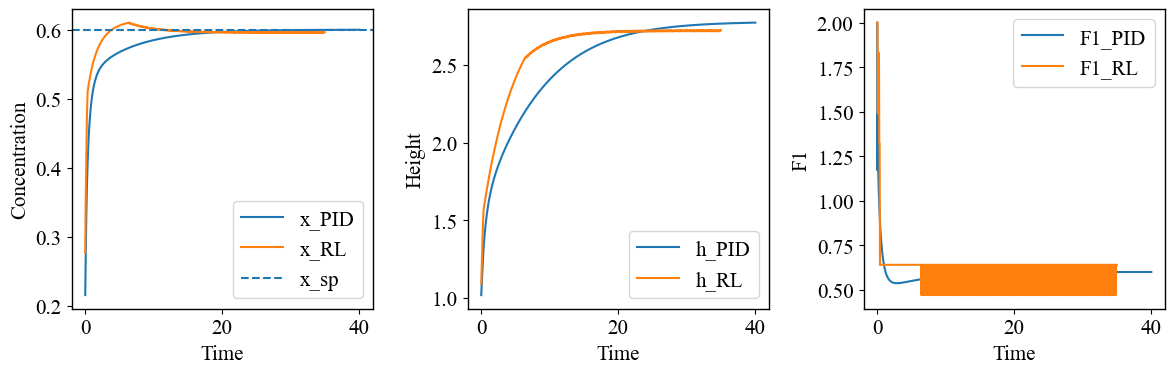

In [142]:
plot_control_results([time, np.array(time_rl)], [x_hist_pid, x_hist_rl], [h_hist_pid, h_hist_rl], [F1_hist_pid, F1_hist_rl], label=["PID", "RL"])